In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from athena_client import query

# estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Imports OK")

✅ Imports OK


In [2]:
df_ano = query("SELECT * FROM sus_pipeline.internacoes_por_ano ORDER BY ano")
df_cid = query("SELECT * FROM sus_pipeline.internacoes_por_cid ORDER BY ano, total_internacoes DESC")
df_atend = query("""
    SELECT ano,
           SUM(total_atendimentos)  AS total_atendimentos,
           SUM(total_masculino)     AS masculino,
           SUM(total_feminino)      AS feminino,
           SUM(atend_uso_drogas)    AS uso_drogas,
           SUM(total_situacao_rua)  AS situacao_rua
    FROM sus_pipeline.atendimentos_por_ano
    GROUP BY ano ORDER BY ano
""")
df_suicidios = query("""
    SELECT ano,
           SUM(total_suicidios)   AS total_suicidios,
           SUM(total_masculino)   AS masculino,
           SUM(total_feminino)    AS feminino,
           SUM(por_enforcamento)  AS enforcamento,
           SUM(por_arma_fogo)     AS arma_fogo,
           SUM(por_envenenamento) AS envenenamento,
           SUM(por_salto)         AS salto
    FROM sus_pipeline.suicidios_por_ano
    GROUP BY ano ORDER BY ano
""")
df_mun = query("""
    SELECT * FROM sus_pipeline.saude_mental_municipios
    WHERE populacao_total > 0
    AND municipio IS NOT NULL
    ORDER BY ano, total_internacoes DESC
""")

# remove anos incompletos
df_ano = df_ano[df_ano['ano'] != '2026']
df_atend = df_atend[~df_atend['ano'].isin(['2017'])]

# converte tipos
for df in [df_ano, df_atend, df_suicidios]:
    df['ano'] = df['ano'].astype(int)

print(f"✅ internacoes_por_ano:        {len(df_ano)} linhas")
print(f"✅ internacoes_por_cid:        {len(df_cid)} linhas")
print(f"✅ atendimentos_por_ano:       {len(df_atend)} linhas")
print(f"✅ suicidios_por_ano:          {len(df_suicidios)} linhas")
print(f"✅ saude_mental_municipios:    {len(df_mun)} linhas")

✅ internacoes_por_ano:        8 linhas
✅ internacoes_por_cid:        3642 linhas
✅ atendimentos_por_ano:       8 linhas
✅ suicidios_por_ano:          7 linhas
✅ saude_mental_municipios:    2330 linhas


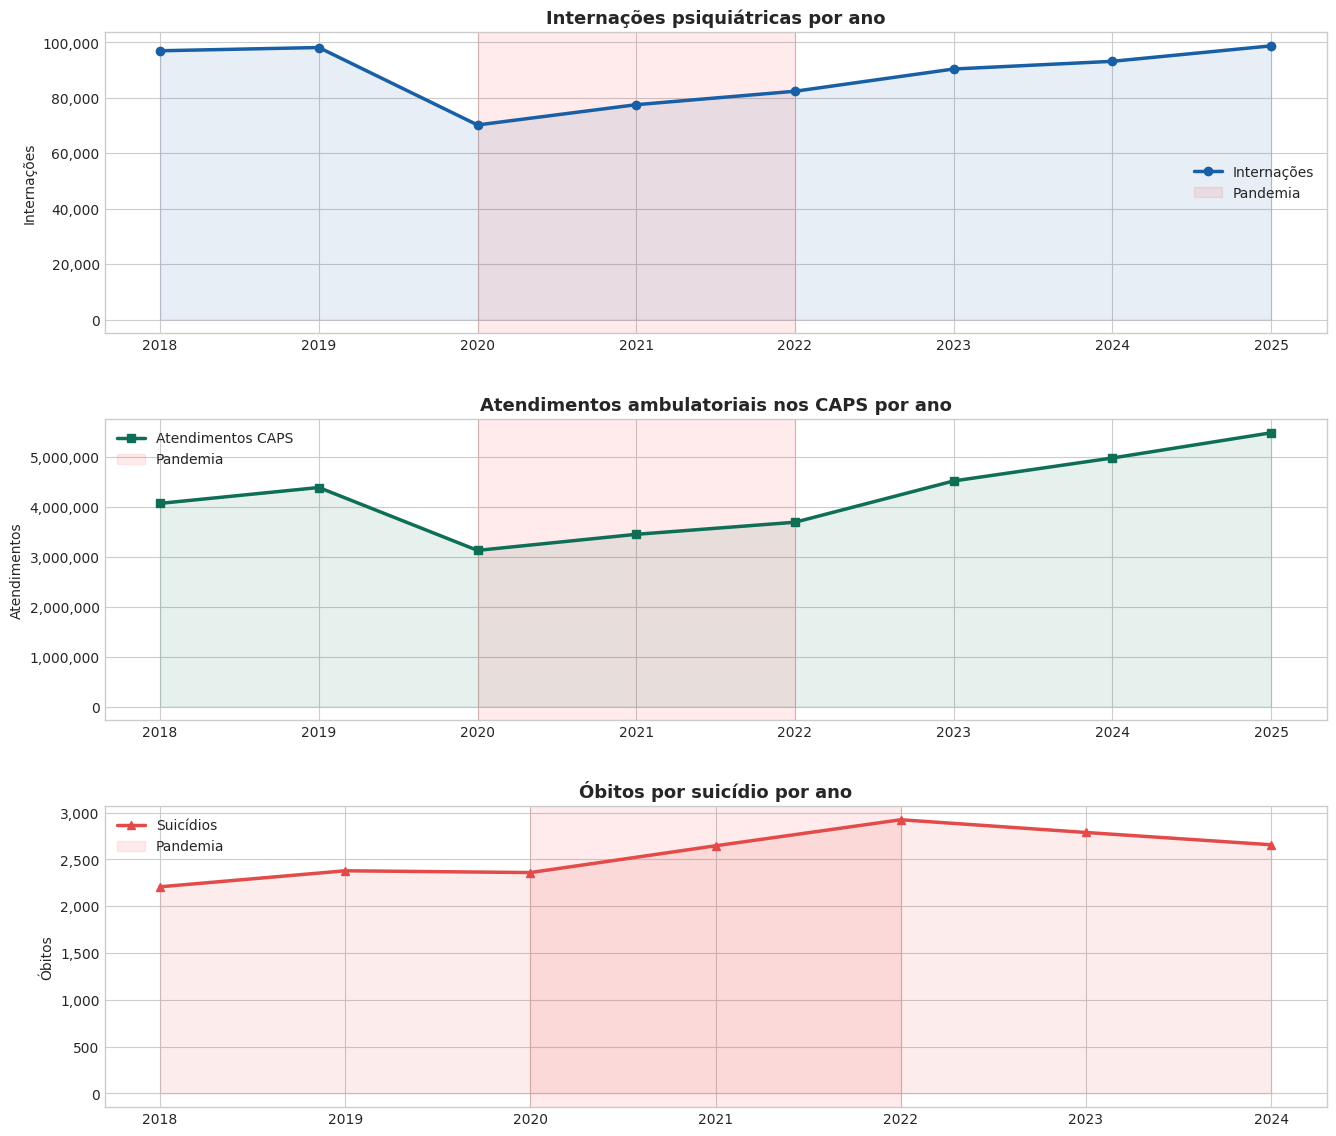

✅ Gráfico salvo!


In [4]:
import os
OUTPUT = os.path.expanduser('~/sus-saude-mental-analytics/output')
os.makedirs(OUTPUT, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# --- internações ---
ax1 = axes[0]
ax1.plot(df_ano['ano'], df_ano['total_internacoes'], 
         marker='o', linewidth=2.5, color='#185FA5', label='Internações')
ax1.fill_between(df_ano['ano'], df_ano['total_internacoes'], alpha=0.1, color='#185FA5')
ax1.axvspan(2020, 2022, alpha=0.08, color='red', label='Pandemia')
ax1.set_title('Internações psiquiátricas por ano', fontsize=13, fontweight='bold')
ax1.set_ylabel('Internações')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend()
ax1.set_xticks(df_ano['ano'])

# --- atendimentos CAPS ---
ax2 = axes[1]
ax2.plot(df_atend['ano'], df_atend['total_atendimentos'],
         marker='s', linewidth=2.5, color='#0F6E56', label='Atendimentos CAPS')
ax2.fill_between(df_atend['ano'], df_atend['total_atendimentos'], alpha=0.1, color='#0F6E56')
ax2.axvspan(2020, 2022, alpha=0.08, color='red', label='Pandemia')
ax2.set_title('Atendimentos ambulatoriais nos CAPS por ano', fontsize=13, fontweight='bold')
ax2.set_ylabel('Atendimentos')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend()
ax2.set_xticks(df_atend['ano'])

# --- suicídios ---
ax3 = axes[2]
ax3.plot(df_suicidios['ano'], df_suicidios['total_suicidios'],
         marker='^', linewidth=2.5, color='#E24B4A', label='Suicídios')
ax3.fill_between(df_suicidios['ano'], df_suicidios['total_suicidios'], alpha=0.1, color='#E24B4A')
ax3.axvspan(2020, 2022, alpha=0.08, color='red', label='Pandemia')
ax3.set_title('Óbitos por suicídio por ano', fontsize=13, fontweight='bold')
ax3.set_ylabel('Óbitos')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.legend()
ax3.set_xticks(df_suicidios['ano'])

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUTPUT}/01_evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

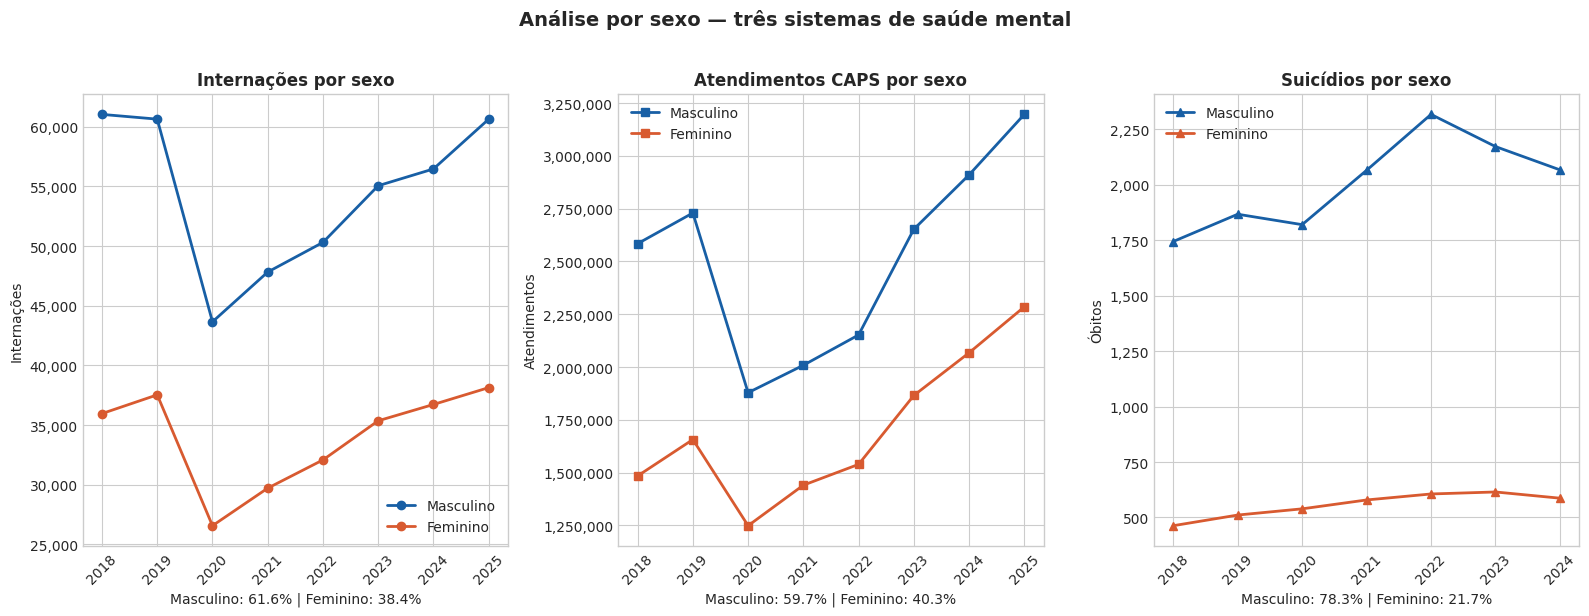

✅ Gráfico salvo!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# internações
df_sexo_int = pd.DataFrame({
    'Ano': list(df_ano['ano']) * 2,
    'Total': list(df_ano['total_masculino']) + list(df_ano['total_feminino']),
    'Sexo': ['Masculino'] * len(df_ano) + ['Feminino'] * len(df_ano)
})
for sexo, color in [('Masculino', '#185FA5'), ('Feminino', '#D85A30')]:
    d = df_sexo_int[df_sexo_int['Sexo'] == sexo]
    axes[0].plot(d['Ano'], d['Total'], marker='o', label=sexo, color=color, linewidth=2)
axes[0].set_title('Internações por sexo', fontweight='bold')
axes[0].set_ylabel('Internações')
axes[0].legend()
axes[0].set_xticks(df_ano['ano'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# atendimentos CAPS
df_sexo_atend = pd.DataFrame({
    'Ano': list(df_atend['ano']) * 2,
    'Total': list(df_atend['masculino']) + list(df_atend['feminino']),
    'Sexo': ['Masculino'] * len(df_atend) + ['Feminino'] * len(df_atend)
})
for sexo, color in [('Masculino', '#185FA5'), ('Feminino', '#D85A30')]:
    d = df_sexo_atend[df_sexo_atend['Sexo'] == sexo]
    axes[1].plot(d['Ano'], d['Total'], marker='s', label=sexo, color=color, linewidth=2)
axes[1].set_title('Atendimentos CAPS por sexo', fontweight='bold')
axes[1].set_ylabel('Atendimentos')
axes[1].legend()
axes[1].set_xticks(df_atend['ano'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# suicídios
df_sexo_suc = pd.DataFrame({
    'Ano': list(df_suicidios['ano']) * 2,
    'Total': list(df_suicidios['masculino']) + list(df_suicidios['feminino']),
    'Sexo': ['Masculino'] * len(df_suicidios) + ['Feminino'] * len(df_suicidios)
})
for sexo, color in [('Masculino', '#185FA5'), ('Feminino', '#D85A30')]:
    d = df_sexo_suc[df_sexo_suc['Sexo'] == sexo]
    axes[2].plot(d['Ano'], d['Total'], marker='^', label=sexo, color=color, linewidth=2)
axes[2].set_title('Suicídios por sexo', fontweight='bold')
axes[2].set_ylabel('Óbitos')
axes[2].legend()
axes[2].set_xticks(df_suicidios['ano'])
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# proporções
for ax, df, col_m, col_f, titulo in [
    (axes[0], df_ano, 'total_masculino', 'total_feminino', 'Internações'),
    (axes[1], df_atend, 'masculino', 'feminino', 'CAPS'),
    (axes[2], df_suicidios, 'masculino', 'feminino', 'Suicídios')
]:
    total_m = df[col_m].sum()
    total_f = df[col_f].sum()
    pct_m = total_m / (total_m + total_f) * 100
    ax.set_xlabel(f'Masculino: {pct_m:.1f}% | Feminino: {100-pct_m:.1f}%', fontsize=10)

plt.suptitle('Análise por sexo — três sistemas de saúde mental', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_analise_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [8]:
# verificação rápida
print("INTERNAÇÕES:")
print(df_ano[['ano', 'total_internacoes', 'total_masculino', 'total_feminino']].to_string())

print("\nATENDIMENTOS CAPS:")
print(df_atend[['ano', 'total_atendimentos', 'masculino', 'feminino']].to_string())

INTERNAÇÕES:
    ano  total_internacoes  total_masculino  total_feminino
0  2018              96993            61029           35964
1  2019              98165            60632           37533
2  2020              70223            43652           26571
3  2021              77536            47821           29715
4  2022              82387            50306           32081
5  2023              90414            55054           35360
6  2024              93185            56459           36726
7  2025              98765            60628           38137

ATENDIMENTOS CAPS:
    ano  total_atendimentos  masculino  feminino
1  2018             4068419    2584409   1484010
2  2019             4386235    2729806   1656429
3  2020             3126712    1878438   1248274
4  2021             3448544    2008346   1440198
5  2022             3690769    2151945   1538824
6  2023             4517815    2652668   1865147
7  2024             4977530    2910215   2067315
8  2025             5481835    3196

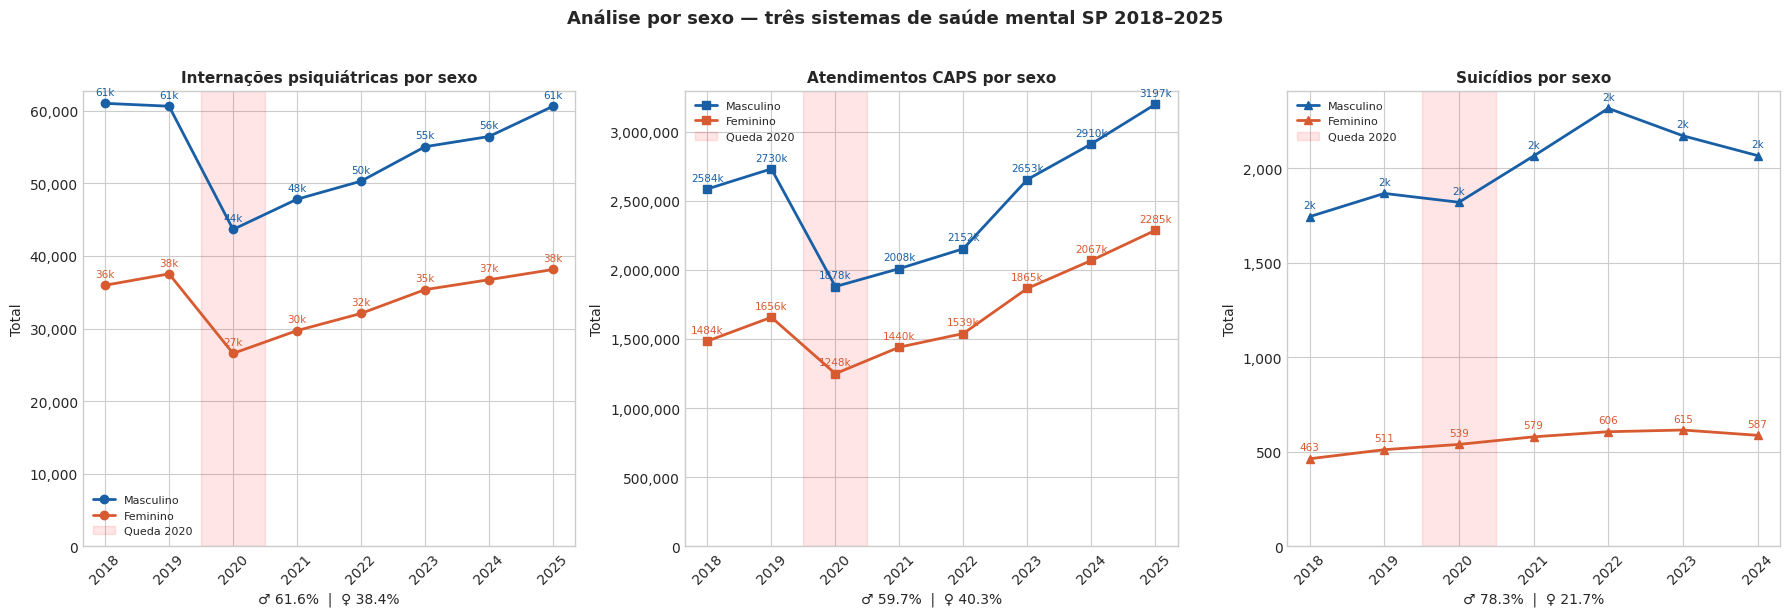

✅ Gráfico salvo!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (df_ano, 'total_masculino', 'total_feminino', 'Internações psiquiátricas por sexo', 'ano', 'o'),
    (df_atend, 'masculino', 'feminino', 'Atendimentos CAPS por sexo', 'ano', 's'),
    (df_suicidios, 'masculino', 'feminino', 'Suicídios por sexo', 'ano', '^'),
]

for ax, (df, col_m, col_f, titulo, col_ano, marker) in zip(axes, datasets):
    anos = df[col_ano]
    
    for col, color, label in [(col_m, '#185FA5', 'Masculino'), (col_f, '#D85A30', 'Feminino')]:
        ax.plot(anos, df[col], marker=marker, label=label, color=color, linewidth=2)
        # anota cada ponto
        for x, y in zip(anos, df[col]):
            ax.annotate(f'{y/1000:.0f}k' if y > 1000 else str(y),
                       xy=(x, y), xytext=(0, 6), textcoords='offset points',
                       ha='center', fontsize=7.5, color=color)
    
    # destaca queda de 2020
    ax.axvspan(2019.5, 2020.5, alpha=0.1, color='red', label='Queda 2020')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Total')
    ax.legend(fontsize=8)
    ax.set_xticks(anos)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylim(bottom=0)  # eixo y começa em zero

    # proporção total
    total_m = df[col_m].sum()
    total_f = df[col_f].sum()
    pct_m = total_m / (total_m + total_f) * 100
    ax.set_xlabel(f'♂ {pct_m:.1f}%  |  ♀ {100-pct_m:.1f}%', fontsize=10)

plt.suptitle('Análise por sexo — três sistemas de saúde mental SP 2018–2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_analise_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

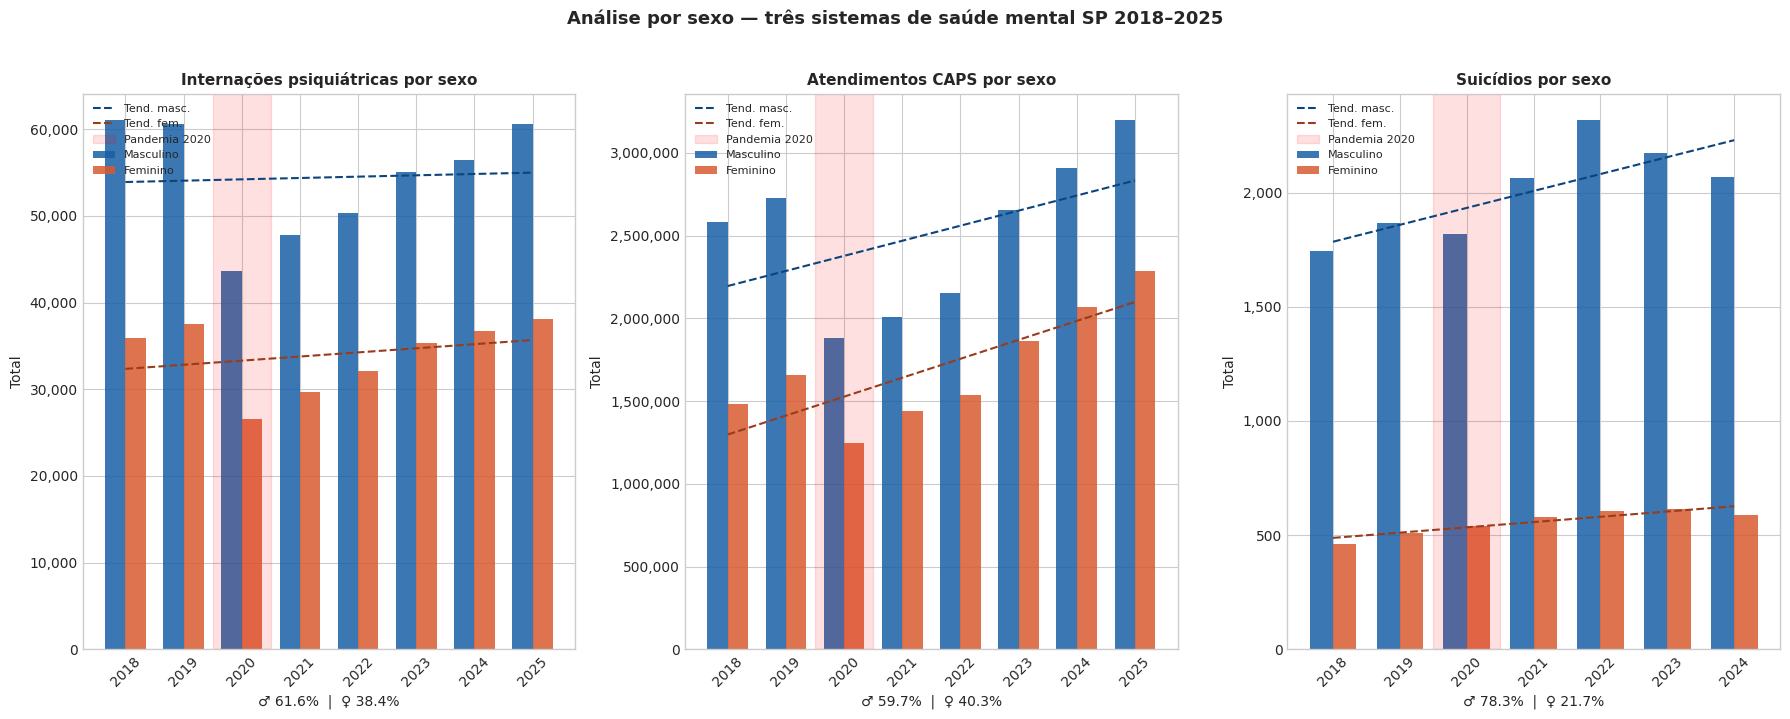

✅ Gráfico salvo!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

datasets = [
    (df_ano, 'total_masculino', 'total_feminino', 'Internações psiquiátricas por sexo', 'ano'),
    (df_atend, 'masculino', 'feminino', 'Atendimentos CAPS por sexo', 'ano'),
    (df_suicidios, 'masculino', 'feminino', 'Suicídios por sexo', 'ano'),
]

for ax, (df, col_m, col_f, titulo, col_ano) in zip(axes, datasets):
    anos = df[col_ano].values
    x = np.arange(len(anos))
    largura = 0.35

    barras_m = ax.bar(x - largura/2, df[col_m], largura,
                      label='Masculino', color='#185FA5', alpha=0.85)
    barras_f = ax.bar(x + largura/2, df[col_f], largura,
                      label='Feminino', color='#D85A30', alpha=0.85)

    # linha de tendência masculino
    z_m = np.polyfit(x, df[col_m], 1)
    p_m = np.poly1d(z_m)
    ax.plot(x, p_m(x), '--', color='#0C447C', linewidth=1.5, label='Tend. masc.')

    # linha de tendência feminino
    z_f = np.polyfit(x, df[col_f], 1)
    p_f = np.poly1d(z_f)
    ax.plot(x, p_f(x), '--', color='#993C1D', linewidth=1.5, label='Tend. fem.')

    # destaca 2020
    idx_2020 = list(anos).index(2020) if 2020 in list(anos) else None
    if idx_2020 is not None:
        ax.axvspan(idx_2020 - 0.5, idx_2020 + 0.5, alpha=0.12, color='red', label='Pandemia 2020')

    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Total')
    ax.set_xticks(x)
    ax.set_xticklabels(anos, rotation=45)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    total_m = df[col_m].sum()
    total_f = df[col_f].sum()
    pct_m = total_m / (total_m + total_f) * 100
    ax.set_xlabel(f'♂ {pct_m:.1f}%  |  ♀ {100-pct_m:.1f}%', fontsize=10)

plt.suptitle('Análise por sexo — três sistemas de saúde mental SP 2018–2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_analise_sexo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [11]:
# verificação rápida
s = df_suicidios
masc_2018 = s[s['ano']==2018]['masculino'].values[0]
masc_2022 = s[s['ano']==2022]['masculino'].values[0]
fem_2018 = s[s['ano']==2018]['feminino'].values[0]
fem_2022 = s[s['ano']==2022]['feminino'].values[0]

print(f"Masculino 2018: {masc_2018} → 2022: {masc_2022} | variação: {(masc_2022/masc_2018-1)*100:.1f}%")
print(f"Feminino  2018: {fem_2018}  → 2022: {fem_2022}  | variação: {(fem_2022/fem_2018-1)*100:.1f}%")

Masculino 2018: 1744 → 2022: 2317 | variação: 32.9%
Feminino  2018: 463  → 2022: 606  | variação: 30.9%


In [12]:
# tendência completa 2018-2024
s = df_suicidios
masc_2024 = s[s['ano']==2024]['masculino'].values[0]
fem_2024 = s[s['ano']==2024]['feminino'].values[0]

print(f"Masculino 2018→2024: {masc_2018} → {masc_2024} | variação: {(masc_2024/masc_2018-1)*100:.1f}%")
print(f"Feminino  2018→2024: {fem_2018}  → {fem_2024}  | variação: {(fem_2024/fem_2018-1)*100:.1f}%")

Masculino 2018→2024: 1744 → 2067 | variação: 18.5%
Feminino  2018→2024: 463  → 587  | variação: 26.8%


In [13]:
# Célula de insight — crescimento de suicídios por sexo
print("""
📊 INSIGHT — Suicídios por sexo (2018–2024)

Masculino: 1.744 → 2.067 (+18.5%)
Feminino:  463   → 587   (+26.8%)

⚠️ Apesar do volume absoluto ser muito menor,
o crescimento proporcional de suicídios femininos
é 45% maior que o masculino no período.

Isso é consistente com a literatura que aponta
aumento de sofrimento psíquico feminino pós-pandemia,
especialmente em mulheres jovens.
""")


📊 INSIGHT — Suicídios por sexo (2018–2024)

Masculino: 1.744 → 2.067 (+18.5%)
Feminino:  463   → 587   (+26.8%)

⚠️ Apesar do volume absoluto ser muito menor,
o crescimento proporcional de suicídios femininos
é 45% maior que o masculino no período.

Isso é consistente com a literatura que aponta
aumento de sofrimento psíquico feminino pós-pandemia,
especialmente em mulheres jovens.



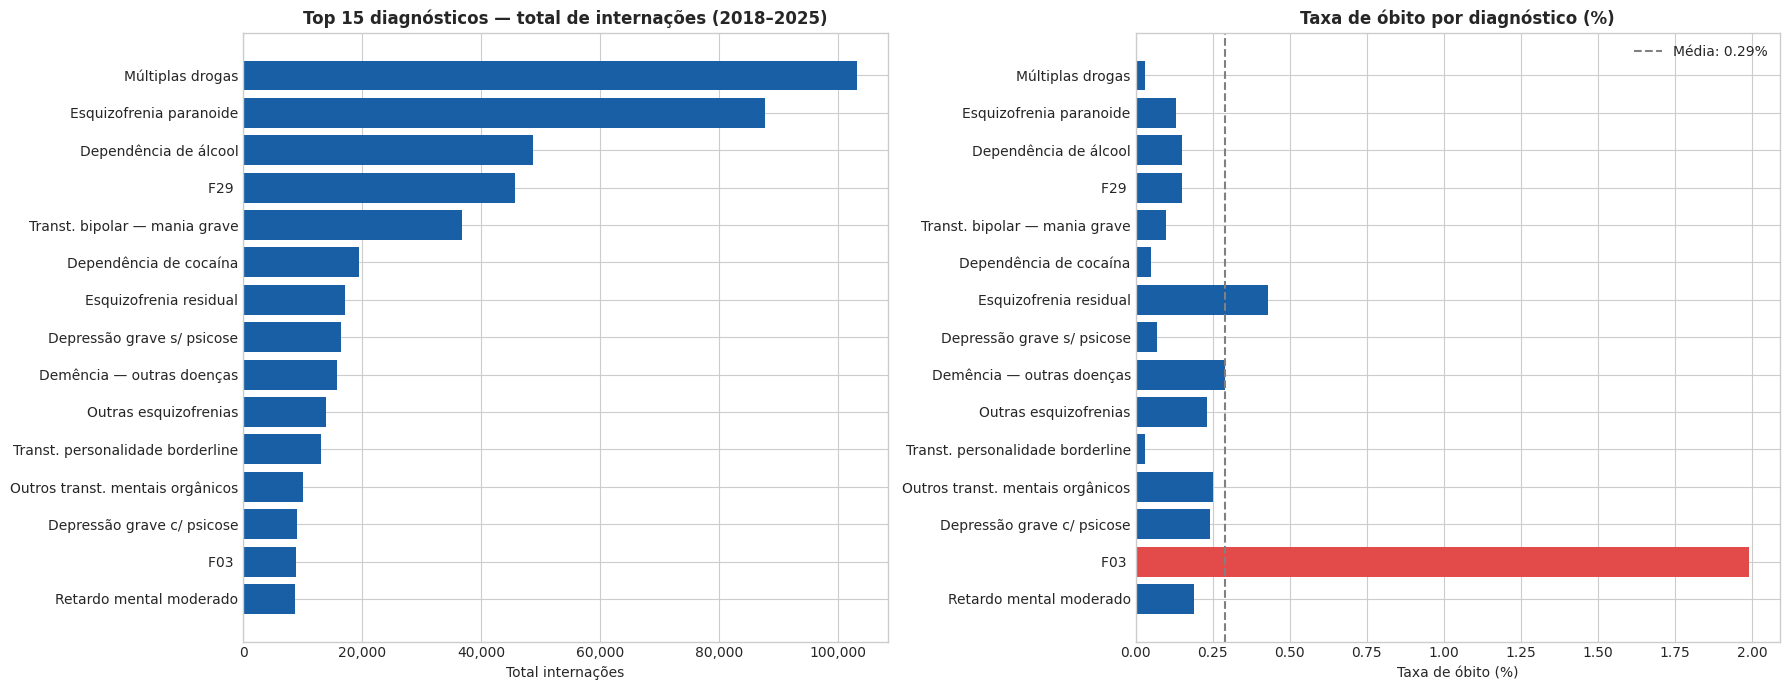

✅ Gráfico salvo!

Top 15 CIDs:
                            descricao  total_internacoes  taxa_obito  media_dias  valor_medio
174                  Múltiplas drogas             103090        0.03         NaN       983.55
183           Esquizofrenia paranoide              87713        0.13         NaN      1122.08
76              Dependência de álcool              48678        0.15         NaN      1159.16
212                              F29               45634        0.15         NaN       700.89
222     Transt. bipolar — mania grave              36714        0.10         NaN       896.57
120            Dependência de cocaína              19485        0.05         NaN       954.46
188            Esquizofrenia residual              17166        0.43         NaN      1335.89
233        Depressão grave s/ psicose              16422        0.07         NaN       595.92
47          Demência — outras doenças              15848        0.29         NaN      2084.91
190             Outras esquiz

In [17]:
df_cid_agg = df_cid.groupby('cid_principal').agg(
    total_internacoes=('total_internacoes', 'sum'),
    total_obitos=('total_obitos', 'sum'),
    media_dias=('media_dias_internacao', 'mean'),
    valor_medio=('valor_medio_internacao', 'mean')
).reset_index()

df_cid_agg['taxa_obito'] = (df_cid_agg['total_obitos'] / df_cid_agg['total_internacoes'] * 100).round(2)

cid_map = {
    'F192': 'Múltiplas drogas',
    'F200': 'Esquizofrenia paranoide',
    'F102': 'Dependência de álcool',
    'F290': 'Psicose não orgânica NE',
    'F29': 'Psicose não orgânica NE',
    'F312': 'Transt. bipolar — mania grave',
    'F142': 'Dependência de cocaína',
    'F205': 'Esquizofrenia residual',
    'F322': 'Depressão grave s/ psicose',
    'F028': 'Demência — outras doenças',
    'F208': 'Outras esquizofrenias',
    'F603': 'Transt. personalidade borderline',
    'F068': 'Outros transt. mentais orgânicos',
    'F323': 'Depressão grave c/ psicose',
    'F03': 'Demência não especificada',
    'F721': 'Retardo mental moderado',
}

df_cid_agg['descricao'] = df_cid_agg['cid_principal'].map(cid_map).fillna(df_cid_agg['cid_principal'])
top15 = df_cid_agg.nlargest(15, 'total_internacoes')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top15['descricao'], top15['total_internacoes'], color='#185FA5')
axes[0].set_title('Top 15 diagnósticos — total de internações (2018–2025)', fontweight='bold')
axes[0].set_xlabel('Total internações')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].invert_yaxis()

cores = ['#E24B4A' if x > 0.5 else '#185FA5' for x in top15['taxa_obito']]
axes[1].barh(top15['descricao'], top15['taxa_obito'], color=cores)
axes[1].set_title('Taxa de óbito por diagnóstico (%)', fontweight='bold')
axes[1].set_xlabel('Taxa de óbito (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=top15['taxa_obito'].mean(), color='gray', linestyle='--',
                label=f'Média: {top15["taxa_obito"].mean():.2f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT}/03_analise_cid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")
print("\nTop 15 CIDs:")
print(top15[['descricao', 'total_internacoes', 'taxa_obito', 'media_dias', 'valor_medio']].to_string())

In [22]:
# verificar quais CIDs do top 15 ainda aparecem como código
print(top15[['cid_principal', 'descricao']].to_string())

    cid_principal                         descricao
174          F192                  Múltiplas drogas
183          F200           Esquizofrenia paranoide
76           F102             Dependência de álcool
212          F29                               F29 
222          F312     Transt. bipolar — mania grave
120          F142            Dependência de cocaína
188          F205            Esquizofrenia residual
233          F322        Depressão grave s/ psicose
47           F028         Demência — outras doenças
190          F208             Outras esquizofrenias
342          F603  Transt. personalidade borderline
64           F068  Outros transt. mentais orgânicos
234          F323        Depressão grave c/ psicose
48           F03                               F03 
393          F721           Retardo mental moderado


In [23]:
# verifica os valores exatos
print(repr(df_cid_agg[df_cid_agg['cid_principal'].str.startswith('F29')]['cid_principal'].values))
print(repr(df_cid_agg[df_cid_agg['cid_principal'].str.startswith('F03')]['cid_principal'].values))

array(['F29 '], dtype=object)
array(['F03 '], dtype=object)


In [24]:
df_cid_agg['cid_principal'] = df_cid_agg['cid_principal'].str.strip()
df_cid_agg['descricao'] = df_cid_agg['cid_principal'].map(cid_map).fillna(df_cid_agg['cid_principal'])
top15 = df_cid_agg.nlargest(15, 'total_internacoes')

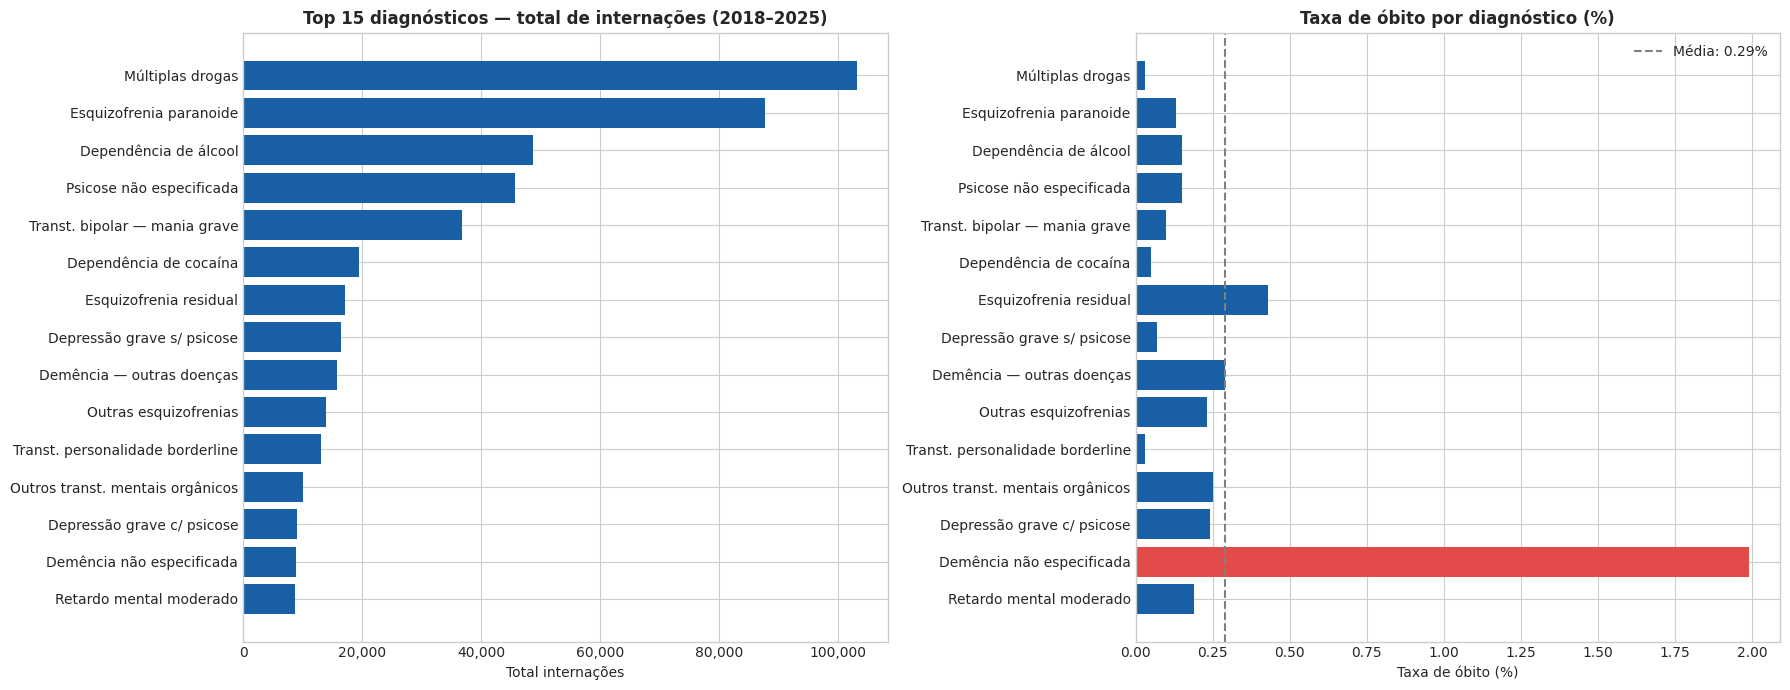

In [26]:
# Célula 5 — análise por CID (versão final)
df_cid_agg = df_cid.groupby('cid_principal').agg(
    total_internacoes=('total_internacoes', 'sum'),
    total_obitos=('total_obitos', 'sum'),
    media_dias=('media_dias_internacao', 'mean'),
    valor_medio=('valor_medio_internacao', 'mean')
).reset_index()

df_cid_agg['taxa_obito'] = (df_cid_agg['total_obitos'] / df_cid_agg['total_internacoes'] * 100).round(2)

# STRIP antes do mapeamento
df_cid_agg['cid_principal'] = df_cid_agg['cid_principal'].str.strip()

cid_map = {
    'F192': 'Múltiplas drogas',
    'F200': 'Esquizofrenia paranoide',
    'F102': 'Dependência de álcool',
    'F29':  'Psicose não especificada',
    'F312': 'Transt. bipolar — mania grave',
    'F142': 'Dependência de cocaína',
    'F205': 'Esquizofrenia residual',
    'F322': 'Depressão grave s/ psicose',
    'F028': 'Demência — outras doenças',
    'F208': 'Outras esquizofrenias',
    'F603': 'Transt. personalidade borderline',
    'F068': 'Outros transt. mentais orgânicos',
    'F323': 'Depressão grave c/ psicose',
    'F03':  'Demência não especificada',
    'F721': 'Retardo mental moderado',
}

df_cid_agg['descricao'] = df_cid_agg['cid_principal'].map(cid_map).fillna(df_cid_agg['cid_principal'])
top15 = df_cid_agg.nlargest(15, 'total_internacoes')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top15['descricao'], top15['total_internacoes'], color='#185FA5')
axes[0].set_title('Top 15 diagnósticos — total de internações (2018–2025)', fontweight='bold')
axes[0].set_xlabel('Total internações')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].invert_yaxis()

cores = ['#E24B4A' if x > 0.5 else '#185FA5' for x in top15['taxa_obito']]
axes[1].barh(top15['descricao'], top15['taxa_obito'], color=cores)
axes[1].set_title('Taxa de óbito por diagnóstico (%)', fontweight='bold')
axes[1].set_xlabel('Taxa de óbito (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=top15['taxa_obito'].mean(), color='gray', linestyle='--',
                label=f'Média: {top15["taxa_obito"].mean():.2f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT}/03_analise_cid.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Célula de insight — Demência não especificada (F03)
print("""
╔══════════════════════════════════════════════════════════════╗
║         INSIGHT — Demência não especificada (F03)           ║
╚══════════════════════════════════════════════════════════════╝

📊 DADO: Taxa de óbito de 2.0% — 7x acima da média geral (0.29%)

🔍 POR QUE É TÃO ALTA?

1. DOENÇA TERMINAL
   Demência é neurodegenerativa e irreversível. A internação
   psiquiátrica frequentemente ocorre no estágio final, quando
   o cuidado domiciliar não é mais possível.

2. PERFIL DE VULNERABILIDADE
   Pacientes idosos com múltiplas comorbidades (diabetes,
   hipertensão, insuficiência cardíaca) — combinação que
   eleva significativamente o risco de óbito hospitalar.

3. DIAGNÓSTICO TARDIO
   "Não especificada" indica ausência de clareza diagnóstica,
   frequentemente associada a diagnóstico tardio e doença
   já em estágio avançado.

4. COMPLICAÇÕES DA INTERNAÇÃO
   Idosos com demência são vulneráveis a: infecções
   hospitalares, pneumonia aspirativa, úlceras de pressão
   e desidratação durante a internação.

⚠️ IMPLICAÇÃO DE POLÍTICA PÚBLICA
   Alta taxa de óbito + alto custo médio (R$ 1.686) sugere
   necessidade de cuidados paliativos e suporte domiciliar
   como alternativa à internação psiquiátrica para demências.
""")


╔══════════════════════════════════════════════════════════════╗
║         INSIGHT — Demência não especificada (F03)           ║
╚══════════════════════════════════════════════════════════════╝

📊 DADO: Taxa de óbito de 2.0% — 7x acima da média geral (0.29%)

🔍 POR QUE É TÃO ALTA?

1. DOENÇA TERMINAL
   Demência é neurodegenerativa e irreversível. A internação
   psiquiátrica frequentemente ocorre no estágio final, quando
   o cuidado domiciliar não é mais possível.

2. PERFIL DE VULNERABILIDADE
   Pacientes idosos com múltiplas comorbidades (diabetes,
   hipertensão, insuficiência cardíaca) — combinação que
   eleva significativamente o risco de óbito hospitalar.

3. DIAGNÓSTICO TARDIO
   "Não especificada" indica ausência de clareza diagnóstica,
   frequentemente associada a diagnóstico tardio e doença
   já em estágio avançado.

4. COMPLICAÇÕES DA INTERNAÇÃO
   Idosos com demência são vulneráveis a: infecções
   hospitalares, pneumonia aspirativa, úlceras de pressão
   e desidrataç

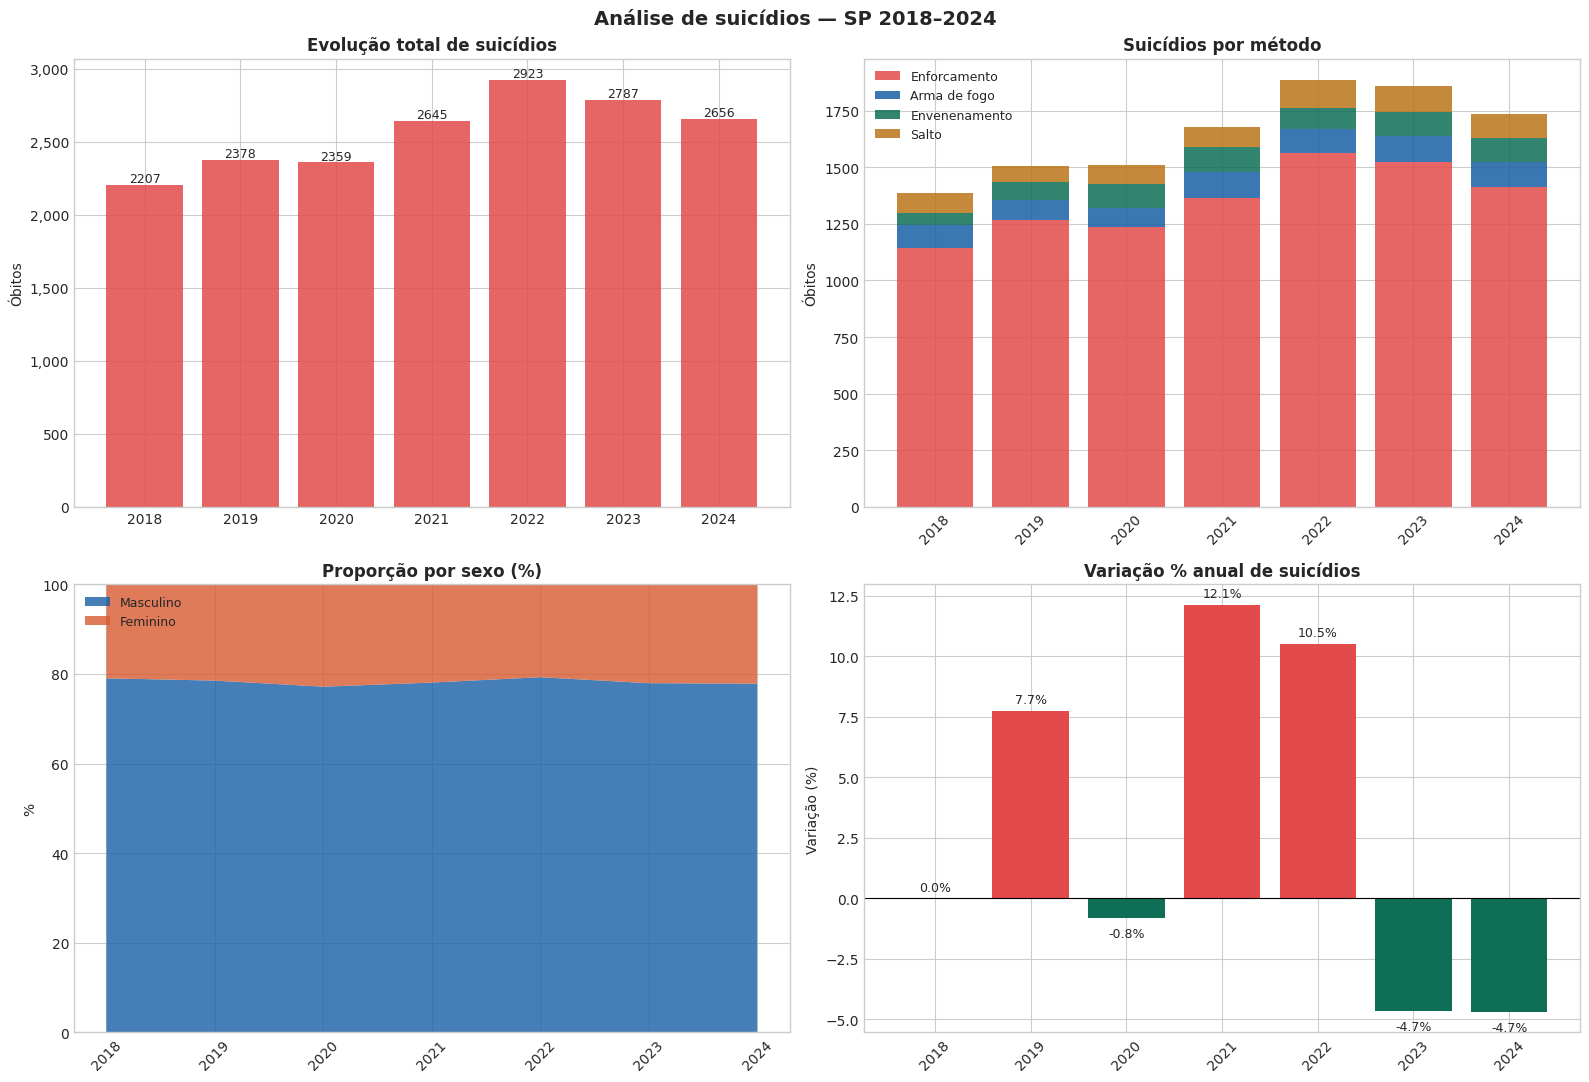

✅ Gráfico salvo!


In [29]:
# Célula 6 — análise de suicídios (evolução como barra)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# evolução total — barra
ax = axes[0, 0]
cores_ev = ['#E24B4A'] * len(df_suicidios)
bars = ax.bar(df_suicidios['ano'], df_suicidios['total_suicidios'], 
              color=cores_ev, alpha=0.85)
for bar, v in zip(bars, df_suicidios['total_suicidios']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(v), ha='center', fontsize=9)
ax.set_title('Evolução total de suicídios', fontweight='bold')
ax.set_ylabel('Óbitos')
ax.set_xticks(df_suicidios['ano'])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# por método — stacked bar
ax = axes[0, 1]
metodos = ['enforcamento', 'arma_fogo', 'envenenamento', 'salto']
labels_metodos = ['Enforcamento', 'Arma de fogo', 'Envenenamento', 'Salto']
cores_metodos = ['#E24B4A', '#185FA5', '#0F6E56', '#BA7517']
bottom = np.zeros(len(df_suicidios))
for metodo, label, cor in zip(metodos, labels_metodos, cores_metodos):
    ax.bar(df_suicidios['ano'], df_suicidios[metodo], bottom=bottom,
           label=label, color=cor, alpha=0.85)
    bottom += df_suicidios[metodo].values
ax.set_title('Suicídios por método', fontweight='bold')
ax.set_ylabel('Óbitos')
ax.legend(fontsize=9)
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)

# proporção por sexo
ax = axes[1, 0]
pct_masc = df_suicidios['masculino'] / df_suicidios['total_suicidios'] * 100
pct_fem = df_suicidios['feminino'] / df_suicidios['total_suicidios'] * 100
ax.stackplot(df_suicidios['ano'], pct_masc, pct_fem,
             labels=['Masculino', 'Feminino'],
             colors=['#185FA5', '#D85A30'], alpha=0.8)
ax.set_title('Proporção por sexo (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 100)

# variação % ano a ano
ax = axes[1, 1]
variacao = df_suicidios['total_suicidios'].pct_change() * 100
cores_var = ['#E24B4A' if v > 0 else '#0F6E56' for v in variacao.fillna(0)]
ax.bar(df_suicidios['ano'], variacao.fillna(0), color=cores_var)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Variação % anual de suicídios', fontweight='bold')
ax.set_ylabel('Variação (%)')
ax.set_xticks(df_suicidios['ano'])
ax.tick_params(axis='x', rotation=45)
for ano, v in zip(df_suicidios['ano'], variacao.fillna(0)):
    ax.text(ano, v + (0.3 if v >= 0 else -0.8), f'{v:.1f}%',
            ha='center', fontsize=9)

plt.suptitle('Análise de suicídios — SP 2018–2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/04_suicidios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

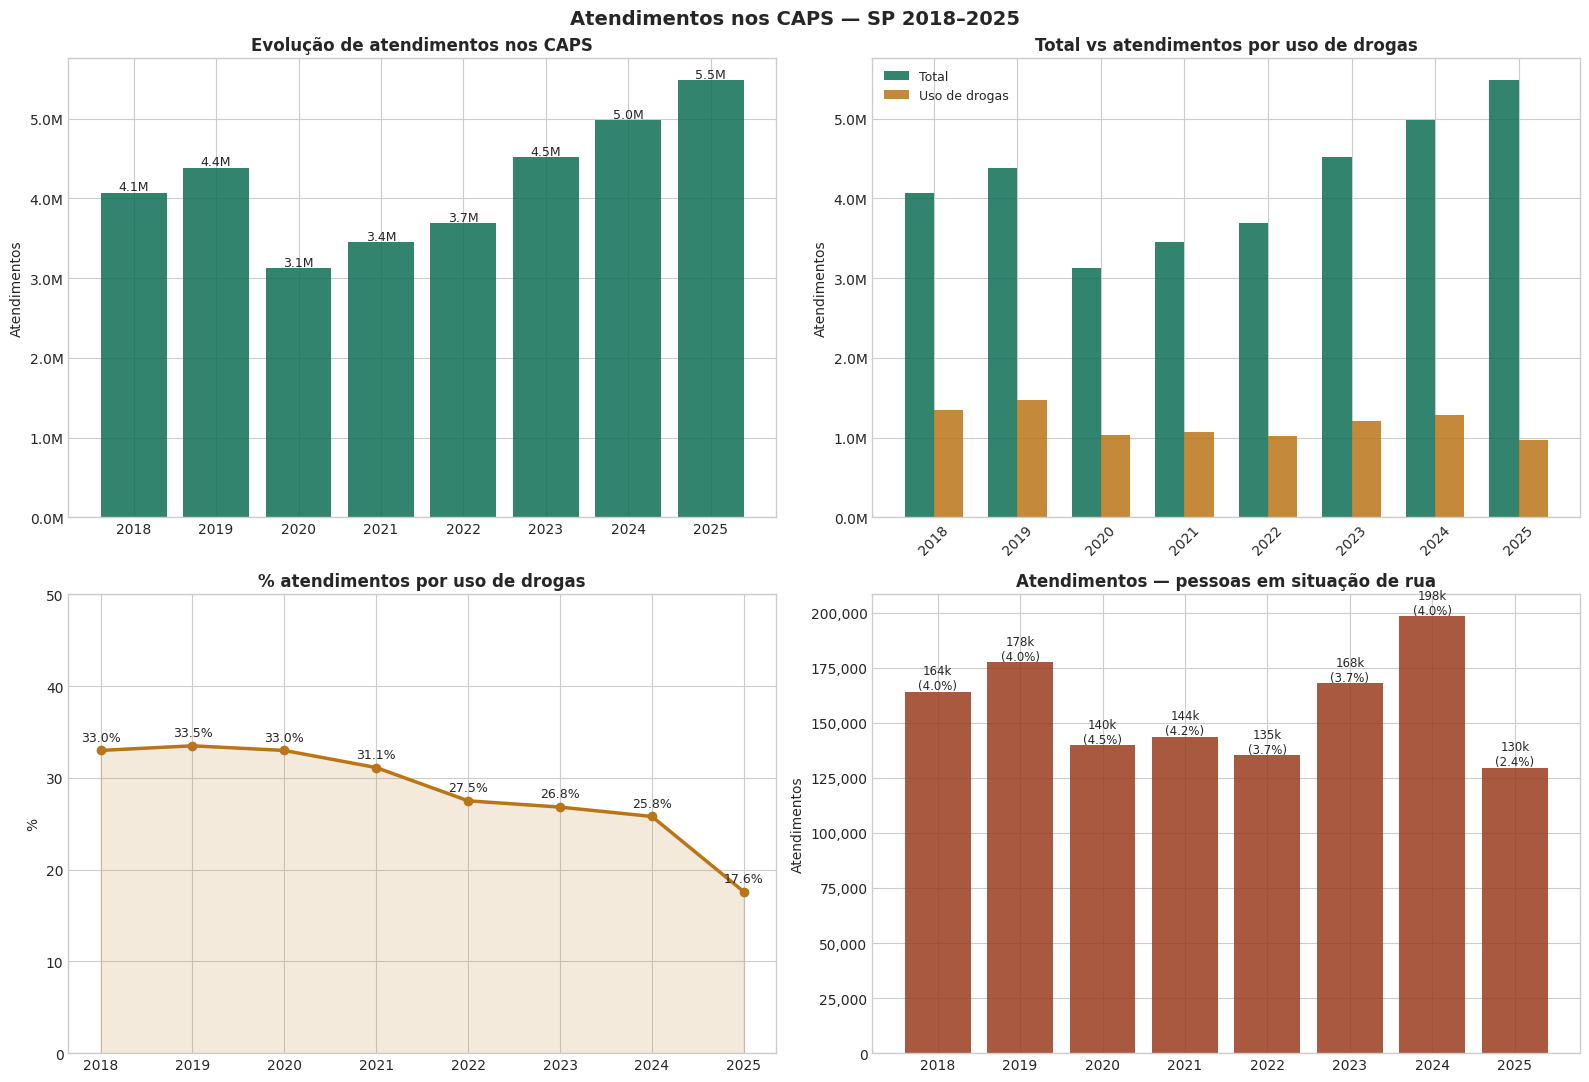

✅ Gráfico salvo!


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# evolução total
ax = axes[0, 0]
bars = ax.bar(df_atend['ano'], df_atend['total_atendimentos'], 
              color='#0F6E56', alpha=0.85)
for bar, v in zip(bars, df_atend['total_atendimentos']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'{v/1e6:.1f}M', ha='center', fontsize=9)
ax.set_title('Evolução de atendimentos nos CAPS', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(df_atend['ano'])
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# uso de drogas vs total
ax = axes[0, 1]
pct_drogas = df_atend['uso_drogas'] / df_atend['total_atendimentos'] * 100
x = np.arange(len(df_atend))
largura = 0.35
ax.bar(x - largura/2, df_atend['total_atendimentos'], largura,
       label='Total', color='#0F6E56', alpha=0.85)
ax.bar(x + largura/2, df_atend['uso_drogas'], largura,
       label='Uso de drogas', color='#BA7517', alpha=0.85)
ax.set_title('Total vs atendimentos por uso de drogas', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(x)
ax.set_xticklabels(df_atend['ano'], rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# % uso de drogas ao longo do tempo
ax = axes[1, 0]
ax.plot(df_atend['ano'], pct_drogas, marker='o', linewidth=2.5, color='#BA7517')
ax.fill_between(df_atend['ano'], pct_drogas, alpha=0.15, color='#BA7517')
for x, y in zip(df_atend['ano'], pct_drogas):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_title('% atendimentos por uso de drogas', fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(df_atend['ano'])
ax.set_ylim(0, 50)

# situação de rua
ax = axes[1, 1]
pct_rua = df_atend['situacao_rua'] / df_atend['total_atendimentos'] * 100
bars = ax.bar(df_atend['ano'], df_atend['situacao_rua'],
              color='#993C1D', alpha=0.85)
for bar, v, p in zip(bars, df_atend['situacao_rua'], pct_rua):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{v/1000:.0f}k\n({p:.1f}%)', ha='center', fontsize=8.5)
ax.set_title('Atendimentos — pessoas em situação de rua', fontweight='bold')
ax.set_ylabel('Atendimentos')
ax.set_xticks(df_atend['ano'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Atendimentos nos CAPS — SP 2018–2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/05_caps_atendimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [31]:
df_2023 = df_mun[df_mun['ano'] == '2023'].copy()

print(f"Municípios com dados em 2023: {len(df_2023)}")
print(f"\nEstatísticas de taxa de internação por 100k hab:")
print(df_2023['taxa_internacao_100k'].describe().round(2))
print(f"\nEstatísticas de taxa de suicídio por 100k hab:")
print(df_2023['taxa_suicidio_100k'].describe().round(2))
print(f"\nTop 10 municípios por taxa de internação:")
print(df_2023.nlargest(10, 'taxa_internacao_100k')[
    ['municipio', 'populacao_total', 'total_internacoes', 
     'taxa_internacao_100k', 'total_caps', 'taxa_suicidio_100k']
].to_string())

Municípios com dados em 2023: 275

Estatísticas de taxa de internação por 100k hab:
count     275.00
mean      332.45
std      1118.86
min         0.35
25%        16.23
50%        63.91
75%       195.50
max     11661.14
Name: taxa_internacao_100k, dtype: float64

Estatísticas de taxa de suicídio por 100k hab:
count   275.00
mean      9.01
std       6.52
min       0.00
25%       5.12
50%       8.33
75%      11.63
max      48.50
Name: taxa_suicidio_100k, dtype: float64

Top 10 municípios por taxa de internação:
                       municipio  populacao_total  total_internacoes  taxa_internacao_100k  total_caps  taxa_suicidio_100k
1286    Espírito Santo do Pinhal            39816               4643              11661.14           2                2.51
1285                     Itapira            72022               6195               8601.54           3                4.17
1291                       Garça            42110               2846               6758.49           4              

/tmp/ipykernel_10330/290582881.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10330/290582881.py:49: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10330/290582881.py:50: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT}/06_municipios.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_10330/290582881.py:50: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUTPUT}/06_municipios.png', dpi=150, bbox_inches='tight')
/home/kellivgs/sus-saude-mental-analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kellivgs/sus-saude-mental-analytics/.venv/lib/python3.12/site-packages/IPython/cor

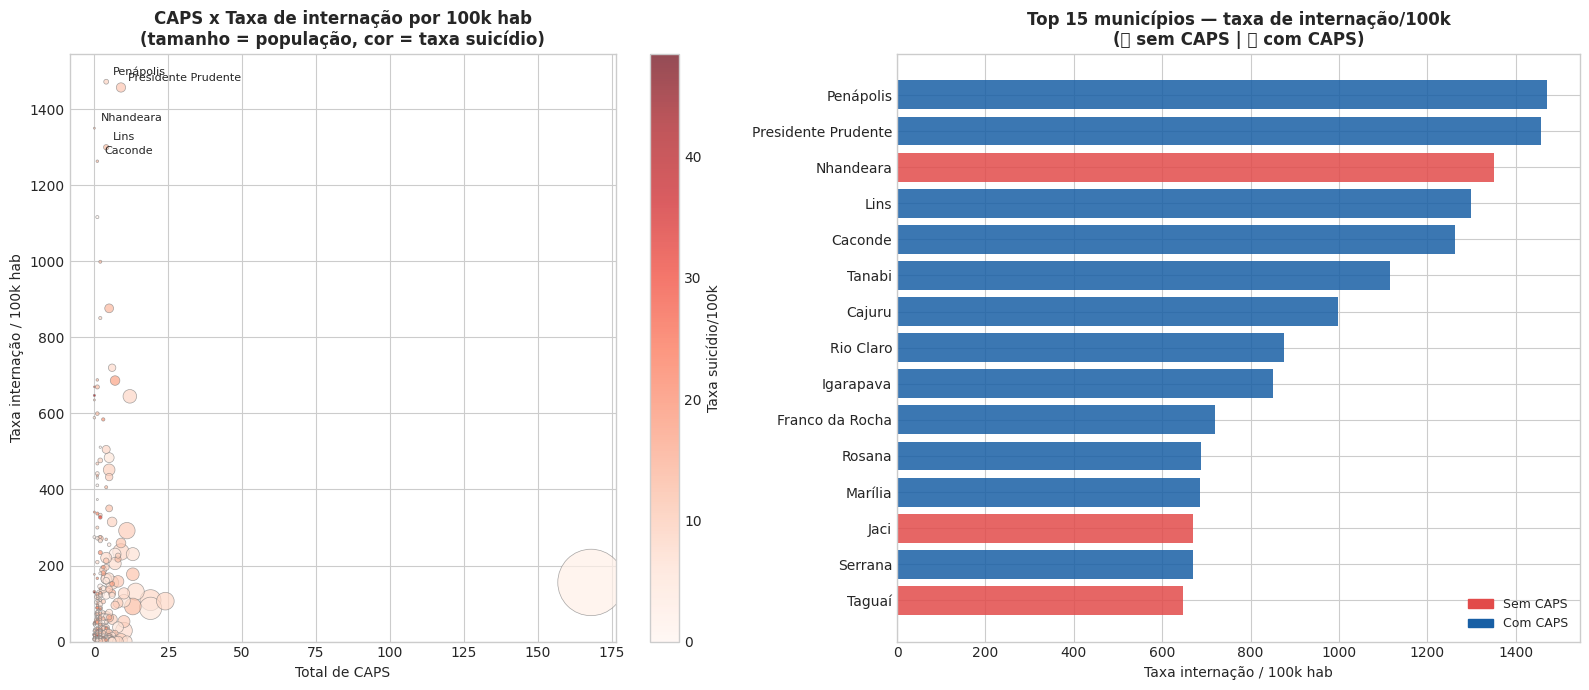

✅ Gráfico salvo!


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# scatter: CAPS x taxa de internação (excluindo outliers extremos)
df_plot = df_2023[df_2023['taxa_internacao_100k'] < 2000].copy()

ax = axes[0]
scatter = ax.scatter(
    df_plot['total_caps'],
    df_plot['taxa_internacao_100k'],
    s=df_plot['populacao_total'] / 5000,
    c=df_plot['taxa_suicidio_100k'],
    cmap='Reds',
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label='Taxa suicídio/100k')

# destaca top 5
top5 = df_plot.nlargest(5, 'taxa_internacao_100k')
for _, row in top5.iterrows():
    ax.annotate(row['municipio'],
                xy=(row['total_caps'], row['taxa_internacao_100k']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_title('CAPS x Taxa de internação por 100k hab\n(tamanho = população, cor = taxa suicídio)',
             fontweight='bold')
ax.set_xlabel('Total de CAPS')
ax.set_ylabel('Taxa internação / 100k hab')
ax.set_ylim(bottom=0)

# top 15 por taxa de internação (sem outliers extremos)
ax = axes[1]
top15_mun = df_plot.nlargest(15, 'taxa_internacao_100k')
cores = ['#E24B4A' if c == 0 else '#185FA5' for c in top15_mun['total_caps']]
bars = ax.barh(top15_mun['municipio'], top15_mun['taxa_internacao_100k'],
               color=cores, alpha=0.85)
ax.set_title('Top 15 municípios — taxa de internação/100k\n(🔴 sem CAPS | 🔵 com CAPS)',
             fontweight='bold')
ax.set_xlabel('Taxa internação / 100k hab')
ax.invert_yaxis()

# legenda manual
from matplotlib.patches import Patch
legenda = [Patch(color='#E24B4A', label='Sem CAPS'),
           Patch(color='#185FA5', label='Com CAPS')]
ax.legend(handles=legenda, fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/06_municipios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [33]:
import plotly.express as px

df_plot = df_2023[df_2023['taxa_internacao_100k'] < 2000].copy()
df_plot['tem_caps'] = df_plot['total_caps'].apply(lambda x: 'Com CAPS' if x > 0 else 'Sem CAPS')
df_plot['populacao_mil'] = (df_plot['populacao_total'] / 1000).round(1)

fig = px.scatter(
    df_plot,
    x='total_caps',
    y='taxa_internacao_100k',
    size='populacao_total',
    color='taxa_suicidio_100k',
    color_continuous_scale='Reds',
    hover_name='municipio',
    hover_data={
        'populacao_mil': True,
        'total_internacoes': True,
        'taxa_internacao_100k': ':.1f',
        'taxa_suicidio_100k': ':.1f',
        'total_caps': True,
        'populacao_total': False
    },
    labels={
        'total_caps': 'Total de CAPS',
        'taxa_internacao_100k': 'Taxa internação / 100k hab',
        'taxa_suicidio_100k': 'Taxa suicídio / 100k',
        'populacao_mil': 'População (mil)'
    },
    title='CAPS x Taxa de internação por município — SP 2023<br><sup>Tamanho = população | Cor = taxa de suicídio | Passe o mouse para detalhes</sup>',
    size_max=50,
    template='plotly_white'
)

fig.update_layout(
    width=1000,
    height=600,
    coloraxis_colorbar=dict(title='Taxa suicídio<br>/100k hab')
)

fig.show()
print("✅ Gráfico interativo — passe o mouse sobre os pontos!")

✅ Gráfico interativo — passe o mouse sobre os pontos!


In [34]:
# salva como HTML interativo
fig.write_html(f'{OUTPUT}/06_municipios_interativo.html')
print("✅ Salvo como HTML interativo!")

✅ Salvo como HTML interativo!


In [35]:
from scipy import stats

df_2023_valid = df_2023[
    (df_2023['taxa_internacao_100k'] < 2000) &
    (df_2023['populacao_total'] > 10000)
].copy()

print(f"Municípios na análise: {len(df_2023_valid)}")

# correlações
pares = [
    ('total_caps', 'taxa_internacao_100k', 'CAPS x Taxa internação'),
    ('total_caps', 'taxa_suicidio_100k', 'CAPS x Taxa suicídio'),
    ('taxa_caps_100k', 'taxa_internacao_100k', 'Taxa CAPS/100k x Taxa internação'),
    ('taxa_caps_100k', 'taxa_suicidio_100k', 'Taxa CAPS/100k x Taxa suicídio'),
    ('pct_domicilios_favelas', 'taxa_internacao_100k', '% Favelas x Taxa internação'),
    ('pct_domicilios_favelas', 'taxa_suicidio_100k', '% Favelas x Taxa suicídio'),
]

print("\n" + "="*65)
print(f"{'Correlação':<40} {'r':>8} {'p-valor':>10} {'Signif.':>8}")
print("="*65)

for x_col, y_col, titulo in pares:
    dados = df_2023_valid[[x_col, y_col]].dropna()
    r, p = stats.pearsonr(dados[x_col], dados[y_col])
    signif = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{titulo:<40} {r:>8.3f} {p:>10.4f} {signif:>8}")

print("="*65)
print("Significância: *** p<0.001 | ** p<0.01 | * p<0.05 | ns não significativo")

Municípios na análise: 251

Correlação                                      r    p-valor  Signif.
CAPS x Taxa internação                      0.019     0.7603       ns
CAPS x Taxa suicídio                       -0.105     0.0978       ns
Taxa CAPS/100k x Taxa internação            0.043     0.4986       ns
Taxa CAPS/100k x Taxa suicídio              0.069     0.2780       ns
% Favelas x Taxa internação                -0.058     0.3641       ns
% Favelas x Taxa suicídio                  -0.187     0.0029       **
Significância: *** p<0.001 | ** p<0.01 | * p<0.05 | ns não significativo


In [36]:
# Célula de insight — correlações
print("""
╔══════════════════════════════════════════════════════════════╗
║              INSIGHT — Análise de correlações               ║
╚══════════════════════════════════════════════════════════════╝

📊 RESULTADOS:

1. CAPS x Internações → r=0.019 (não significativo)
   Quantidade de CAPS não se correlaciona com taxa de internação.
   Isso é esperado: municípios com mais CAPS são maiores e 
   internam mais em termos absolutos, mas a taxa por habitante
   não muda.

2. CAPS x Suicídio → r=-0.105 (não significativo, p=0.097)
   Tendência negativa — mais CAPS associado a menos suicídio —
   mas sem significância estatística com os dados disponíveis.
   Pode ser efeito real que precisaria de série temporal maior.

3. % Favelas x Suicídio → r=-0.187 (**p=0.003)
   ÚNICO resultado significativo: municípios com mais domicílios
   em favelas têm MENOS suicídios por 100k hab.

⚠️ INTERPRETAÇÃO DO RESULTADO PARADOXAL (% Favelas x Suicídio):

Isso parece contraintuitivo mas tem explicação na literatura:

- "Paradoxo da integração social" — comunidades de baixa renda
  frequentemente têm laços sociais mais fortes, fator protetor
  contra suicídio (Durkheim, 1897)

- Subnotificação — mortes em favelas podem ser registradas como
  causas externas indeterminadas em vez de suicídio

- Perfil demográfico — favelas têm população mais jovem, e
  suicídio é mais comum em adultos de meia-idade e idosos

- Viés de seleção — municípios com mais favelas são maiores
  (ex: São Paulo, Guarulhos), onde o denominador populacional
  dilui a taxa

🔍 LIMITAÇÃO IMPORTANTE:
   Análise ecológica (por município) não permite inferência
   individual — é a falácia ecológica. Correlações aqui
   refletem padrões municipais, não individuais.
""")


╔══════════════════════════════════════════════════════════════╗
║              INSIGHT — Análise de correlações               ║
╚══════════════════════════════════════════════════════════════╝

📊 RESULTADOS:

1. CAPS x Internações → r=0.019 (não significativo)
   Quantidade de CAPS não se correlaciona com taxa de internação.
   Isso é esperado: municípios com mais CAPS são maiores e 
   internam mais em termos absolutos, mas a taxa por habitante
   não muda.

2. CAPS x Suicídio → r=-0.105 (não significativo, p=0.097)
   Tendência negativa — mais CAPS associado a menos suicídio —
   mas sem significância estatística com os dados disponíveis.
   Pode ser efeito real que precisaria de série temporal maior.

3. % Favelas x Suicídio → r=-0.187 (**p=0.003)
   ÚNICO resultado significativo: municípios com mais domicílios
   em favelas têm MENOS suicídios por 100k hab.

⚠️ INTERPRETAÇÃO DO RESULTADO PARADOXAL (% Favelas x Suicídio):

Isso parece contraintuitivo mas tem explicação na literatu

In [40]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

pares_plot = [
    ('total_caps', 'taxa_internacao_100k', 'CAPS x Taxa de internação', 'r=0.019, ns', False),
    ('total_caps', 'taxa_suicidio_100k', 'CAPS x Taxa de suicídio', 'r=-0.105, ns', False),
    ('taxa_caps_100k', 'taxa_internacao_100k', 'Taxa CAPS/100k x Taxa internação', 'r=0.043, ns', False),
    ('taxa_caps_100k', 'taxa_suicidio_100k', 'Taxa CAPS/100k x Taxa suicídio', 'r=0.069, ns', False),
    ('pct_domicilios_favelas', 'taxa_internacao_100k', '% Favelas x Taxa internação', 'r=-0.058, ns', False),
    ('pct_domicilios_favelas', 'taxa_suicidio_100k', '% Favelas x Taxa suicídio', 'r=-0.187, **', True),
]

fig = make_subplots(rows=2, cols=3,
                    subplot_titles=[f'{t}<br><sup>{s}</sup>' for _, _, t, s, _ in pares_plot])

for idx, (x_col, y_col, titulo, stats_label, significativo) in enumerate(pares_plot):
    row = idx // 3 + 1
    col = idx % 3 + 1

    dados = df_2023_valid[[x_col, y_col, 'municipio', 'populacao_total',
                            'total_internacoes']].dropna().copy()

    cor = '#E24B4A' if significativo else '#185FA5'

    fig.add_trace(go.Scatter(
        x=dados[x_col],
        y=dados[y_col],
        mode='markers',
        marker=dict(
            size=8,
            color=cor,
            opacity=0.6,
            line=dict(width=0.5, color='gray')
        ),
        text=dados['municipio'],
        customdata=dados[['populacao_total', 'total_internacoes']].values,
        hovertemplate=(
            '<b>%{text}</b><br>'
            f'{x_col}: %{{x:.2f}}<br>'
            f'{y_col}: %{{y:.2f}}<br>'
            'População: %{customdata[0]:,.0f}<br>'
            'Internações: %{customdata[1]:,.0f}<br>'
            '<extra></extra>'
        ),
        showlegend=False
    ), row=row, col=col)

fig.update_layout(
    title='Correlações — infraestrutura x desfechos em saúde mental<br><sup>SP 2023 | municípios com pop > 10k | passe o mouse para detalhes</sup>',
    height=700,
    width=1100,
    template='plotly_white'
)

# limita eixos Y para remover distorção
for i in range(1, 4):
    fig.update_yaxes(range=[0, 500], row=1, col=i)
for i in range(1, 4):
    fig.update_yaxes(range=[0, 50], row=2, col=i)

fig.show()
fig.write_html(f'{OUTPUT}/07_correlacoes_interativo.html')
print("✅ Salvo!")

✅ Salvo!


In [42]:
df_idade = query("""
    SELECT 
        ano,
        CASE 
            WHEN idade < 18 THEN '1_0-17 crianca/adolescente'
            WHEN idade BETWEEN 18 AND 29 THEN '2_18-29 adulto jovem'
            WHEN idade BETWEEN 30 AND 44 THEN '3_30-44 adulto'
            WHEN idade BETWEEN 45 AND 59 THEN '4_45-59 meia-idade'
            WHEN idade BETWEEN 60 AND 74 THEN '5_60-74 idoso jovem'
            WHEN idade >= 75 THEN '6_75+ idoso'
            ELSE '7_Ignorado'
        END AS faixa_etaria,
        COUNT(*) AS total_internacoes,
        SUM(obito) AS total_obitos,
        ROUND(SUM(obito) * 100.0 / COUNT(*), 2) AS taxa_obito
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE idade IS NOT NULL
    AND ano NOT IN ('2026')
    GROUP BY ano,
        CASE 
            WHEN idade < 18 THEN '1_0-17 crianca/adolescente'
            WHEN idade BETWEEN 18 AND 29 THEN '2_18-29 adulto jovem'
            WHEN idade BETWEEN 30 AND 44 THEN '3_30-44 adulto'
            WHEN idade BETWEEN 45 AND 59 THEN '4_45-59 meia-idade'
            WHEN idade BETWEEN 60 AND 74 THEN '5_60-74 idoso jovem'
            WHEN idade >= 75 THEN '6_75+ idoso'
            ELSE '7_Ignorado'
        END
    ORDER BY ano, faixa_etaria
""")

print(f"✅ faixa etária: {len(df_idade)} linhas")
print(df_idade.head(10).to_string())

✅ faixa etária: 48 linhas
    ano                faixa_etaria  total_internacoes  total_obitos  taxa_obito
0  2018  1_0-17 crianca/adolescente               2714             3        0.11
1  2018        2_18-29 adulto jovem              18326            10        0.05
2  2018              3_30-44 adulto              31621            53        0.17
3  2018          4_45-59 meia-idade              27647            83        0.30
4  2018         5_60-74 idoso jovem              12503            84        0.67
5  2018                 6_75+ idoso               4182            61        1.46
6  2019  1_0-17 crianca/adolescente               3176             3        0.09
7  2019        2_18-29 adulto jovem              19973            20        0.10
8  2019              3_30-44 adulto              33315            37        0.11
9  2019          4_45-59 meia-idade              26642            80        0.30


In [43]:
print("\nRaças únicas encontradas:")
print(df_raca['raca_cor'].unique())
print("\nDistribuição total por raça:")
print(df_raca.groupby('raca_cor')['total_internacoes'].sum().sort_values(ascending=False))


Raças únicas encontradas:
['01' '03' '99' '02' '04' '05']

Distribuição total por raça:
raca_cor
01    382657
03    208146
02     64342
99     48431
04      4021
05        71
Name: total_internacoes, dtype: Int64
